<a href="https://colab.research.google.com/github/Gustavo-Bruges/Ciencia_de_Datos_Docencia/blob/master/EDA_reviews_no_estructurados.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>





# EDA para Datos No Estructurados

Análisis exploratorio de datos textuales utilizando Google Colab y Python.

Dataset: `reviews.csv`


In [1]:
from google.colab import drive   # Importa el módulo 'drive' de google.colab para montar Google Drive en Colab
drive.mount('/content/drive')     # Monta Google Drive en la ruta '/content/drive' para acceder a archivos desde el notebook

Mounted at /content/drive


In [2]:
import os
os.chdir('/content/drive/MyDrive/ciencia_de_datos')

## Importar librerías

In [4]:

# Importar pandas para manipulación de datos (DataFrames)
import pandas as pd

# Importar numpy para operaciones numéricas y arrays
import numpy as np

# Importar matplotlib.pyplot para crear gráficos y visualizaciones
import matplotlib.pyplot as plt

# Importar seaborn para gráficos estadísticos avanzados (basado en matplotlib)
import seaborn as sns

# Importar WordCloud para generar nubes de palabras a partir de texto
from wordcloud import WordCloud

# Importar Counter para contar frecuencias de elementos en una lista
from collections import Counter

# Importar nltk (Natural Language Toolkit) para procesamiento de lenguaje natural
import nltk

# Importar stopwords (palabras vacías como "el", "la", "y", etc.) desde nltk.corpus
from nltk.corpus import stopwords

# Importar word_tokenize para dividir texto en palabras (tokens)
from nltk.tokenize import word_tokenize

# Importar re (expresiones regulares) para limpiar y manipular texto
import re

# Descargar los datos de 'punkt' (modelo para tokenización) necesarios para word_tokenize
nltk.download('punkt')

# Descargar la lista de stopwords en varios idiomas (incluyendo español)
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

## Cargar archivo

In [ ]:

#from google.colab import files

#uploaded = files.upload() #opción para cargar desde disco duro


Saving reviews.csv to reviews (1).csv


## Leer dataset

In [5]:

reviews = pd.read_csv('reviews.csv')
reviews.head()


,key,author,date,stars,title,helpful_yes,helpful_no,text
0,0_breyers,LABEL READER,2020-04-17,2,EVER INCREASING INGEDIENTS LIST.,81,3,Not the long ago Breyers set itself apart from...
1,0_breyers,AK in WA,2020-06-09,1,This is NO LONGER the Breyers We Used to Know,94,2,I must agree with many one-star ratings here. ...
2,0_breyers,wing18,2020-09-29,2,Not as good as the natural they used to make!!,72,3,This natural vanilla ice cream is not nearly a...
3,0_breyers,sabrinas,2018-07-08,1,Better before,421,19,Breyers natural vanilla used to be my holy Gra...
4,0_breyers,Scootonout,2018-09-27,1,Very disappointed,36,0,Bryers vanilla was the only ice cream I would ...


In [ ]:
reviews.tail()

,key,author,date,stars,title,helpful_yes,helpful_no,text
5002,68_breyers,Randi,2020-04-22,1,Terrible missing the chocolate ice cream,0,0,There was no chocolate ice cream in this at al...
5003,68_breyers,Bethie,2020-09-08,1,Terrible,0,0,This ice cream has no flavor at all. No one in...
5004,68_breyers,Nshaw1994,2020-09-09,5,Flavor of the week!,0,0,Absolutely love this flavor! The only thing th...
5005,68_breyers,PamelaG,2020-06-01,5,Love this flavor!!,0,0,Brilliant combo - love the cheesecake and brow...
5006,68_breyers,Fanchon,2020-08-22,5,Great,0,0,Has a delicious taste with all natural ingredi...


In [6]:

reviews.shape


(5007, 8)

## Información general

In [7]:

reviews.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5007 entries, 0 to 5006
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   key          5007 non-null   object
 1   author       5007 non-null   object
 2   date         5007 non-null   object
 3   stars        5007 non-null   int64 
 4   title        3062 non-null   object
 5   helpful_yes  5007 non-null   int64 
 6   helpful_no   5007 non-null   int64 
 7   text         5007 non-null   object
dtypes: int64(3), object(5)
memory usage: 313.1+ KB


## Valores faltantes

In [ ]:

reviews.isnull().sum()


,0
key,0
author,0
date,0
stars,0
title,1945
helpful_yes,0
helpful_no,0
text,0


## Distribución de estrellas

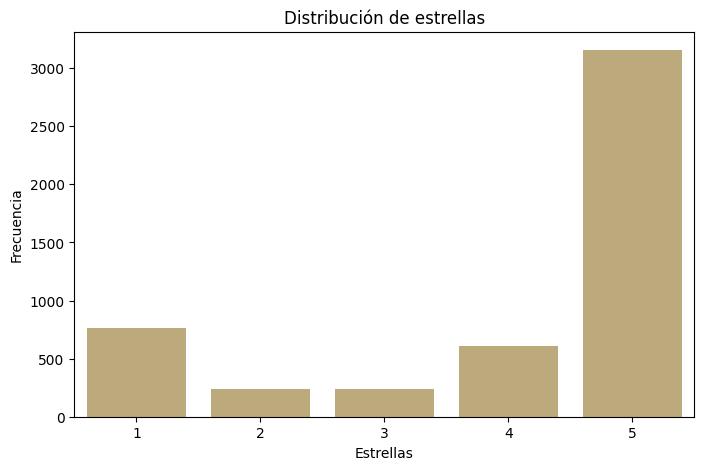

In [8]:

plt.figure(figsize=(8,5))
sns.countplot(x='stars', data=reviews,color= '#C6AF72')

plt.title('Distribución de estrellas')
plt.xlabel('Estrellas')
plt.ylabel('Frecuencia')

plt.show()


## Longitud de caracteres

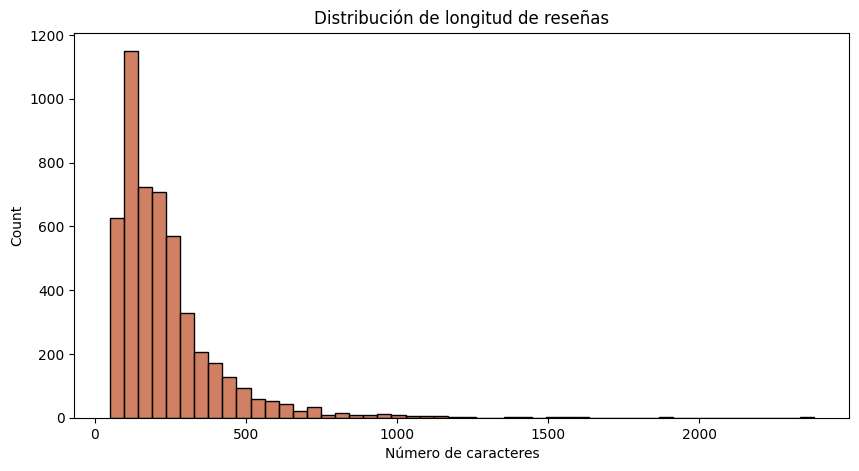

In [15]:

reviews['char_length'] = reviews['text'].astype(str).apply(len)

plt.figure(figsize=(10,5))
sns.histplot(reviews['char_length'], bins=50, color= '#C45630')

plt.title('Distribución de longitud de reseñas')
plt.xlabel('Número de caracteres')

plt.show()


## Número de palabras

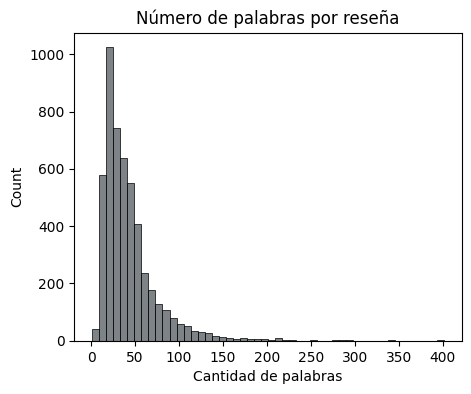

In [18]:

reviews['word_count'] = reviews['text'].astype(str).apply(lambda x: len(x.split()))

plt.figure(figsize=(5,4))
sns.histplot(reviews['word_count'], bins=50, color = '#515A5D')

plt.title('Número de palabras por reseña')
plt.xlabel('Cantidad de palabras')

plt.show()


## Longitud vs estrellas

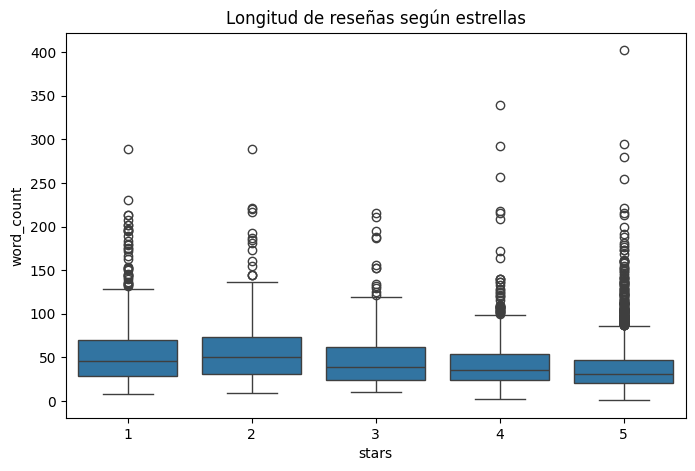

In [ ]:

plt.figure(figsize=(8,5))

sns.boxplot(x='stars',
            y='word_count',
            data=reviews)

plt.title('Longitud de reseñas según estrellas')

plt.show()


In [27]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [30]:
texto ='¿Una mañana gris de la calle corrientes el sapo salto sobre el auto?'


In [31]:
word_tokenize(texto)

['¿Una',
 'mañana',
 'gris',
 'de',
 'la',
 'calle',
 'corrientes',
 'el',
 'sapo',
 'salto',
 'sobre',
 'el',
 'auto',
 '?']

## Limpieza básica de texto

In [32]:

# Importar conjunto de stopwords (palabras vacías) en inglés desde NLTK
stop_words = set(stopwords.words('english'))

def clean_text(text):
    # Convertir el texto a minúsculas para uniformidad
    text = text.lower()
    # Eliminar URLs (http, https, etc.)
    text = re.sub(r'http\S+', '', text)
    # Eliminar cualquier carácter que no sea letra o espacio (signos de puntuación, números, etc.)
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Tokenizar el texto limpio (dividir en palabras individuales)
    tokens = word_tokenize(text)

    # Filtrar tokens: conservar solo aquellos que no estén en la lista de stopwords
    tokens = [word for word in tokens if word not in stop_words]

    # Unir los tokens filtrados nuevamente en una cadena de texto
    return ' '.join(tokens)

# Aplicar la función clean_text a la columna 'text' del DataFrame 'reviews'
# Convertir cada valor a string por si hubiera valores nulos o no textuales
reviews['clean_text'] = reviews['text'].astype(str).apply(clean_text)

# Mostrar las primeras filas con el texto original y el texto limpio para verificar
reviews[['text','clean_text']].head()


,text,clean_text
0,Not the long ago Breyers set itself apart from...,long ago breyers set apart brands using milk c...
1,I must agree with many one-star ratings here. ...,must agree many onestar ratings main beef huge...
2,This natural vanilla ice cream is not nearly a...,natural vanilla ice cream nearly good used don...
3,Breyers natural vanilla used to be my holy Gra...,breyers natural vanilla used holy grail ice cr...
4,Bryers vanilla was the only ice cream I would ...,bryers vanilla ice cream would eat loved simpl...


## Palabras más frecuentes

In [ ]:
# Unir todo el texto limpio en una sola cadena larga
all_words = ' '.join(reviews['clean_text'])

# Crear un contador de frecuencias de cada palabra (separando por espacios)
word_freq = Counter(all_words.split())

# Crear un DataFrame con las 20 palabras más comunes y sus frecuencias
common_words = pd.DataFrame(
    word_freq.most_common(20),
    columns=['word','freq']
)

# Mostrar el DataFrame resultante (las 20 palabras más frecuentes en todo el corpus)
common_words

,word,freq
0,ice,5654
1,cream,5641
2,breyers,1785
3,love,1728
4,chocolate,1654
5,flavor,1622
6,vanilla,1610
7,like,1483
8,taste,1336
9,good,1258


In [ ]:
custom_stopwords = {
    'ice',
    'cream',
    'breyers'
}

stop_words.update(custom_stopwords)
reviews['clean_text'] = reviews['clean_text'].apply(
    lambda x: ' '.join(
        word for word in x.split()
        if word not in stop_words
    )
)

## Visualización palabras frecuentes

In [ ]:
from collections import Counter

all_words = ' '.join(reviews['clean_text']).split()

word_freq = Counter(all_words)

In [ ]:
common_words = pd.DataFrame(
    word_freq.most_common(20),
    columns=['word', 'freq']
)

common_words

,word,freq
0,love,1728
1,chocolate,1654
2,flavor,1622
3,vanilla,1610
4,like,1483
5,taste,1336
6,good,1258
7,creamy,1044
8,one,890
9,great,866


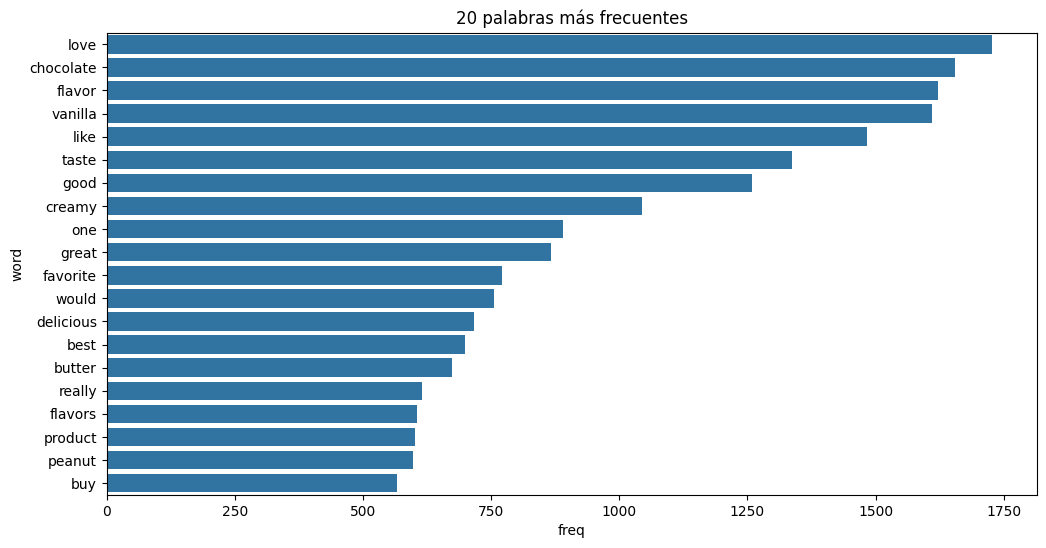

In [ ]:

plt.figure(figsize=(12,6))

sns.barplot(data=common_words,
            x='freq',
            y='word')

plt.title('20 palabras más frecuentes')

plt.show()


## Nube de palabras

In [ ]:
text = ' '.join(reviews['clean_text'])
wordcloud = WordCloud(
    width=1400,
    height=700,
    background_color='white',
    collocations=False,
    max_words=100
).generate(text)


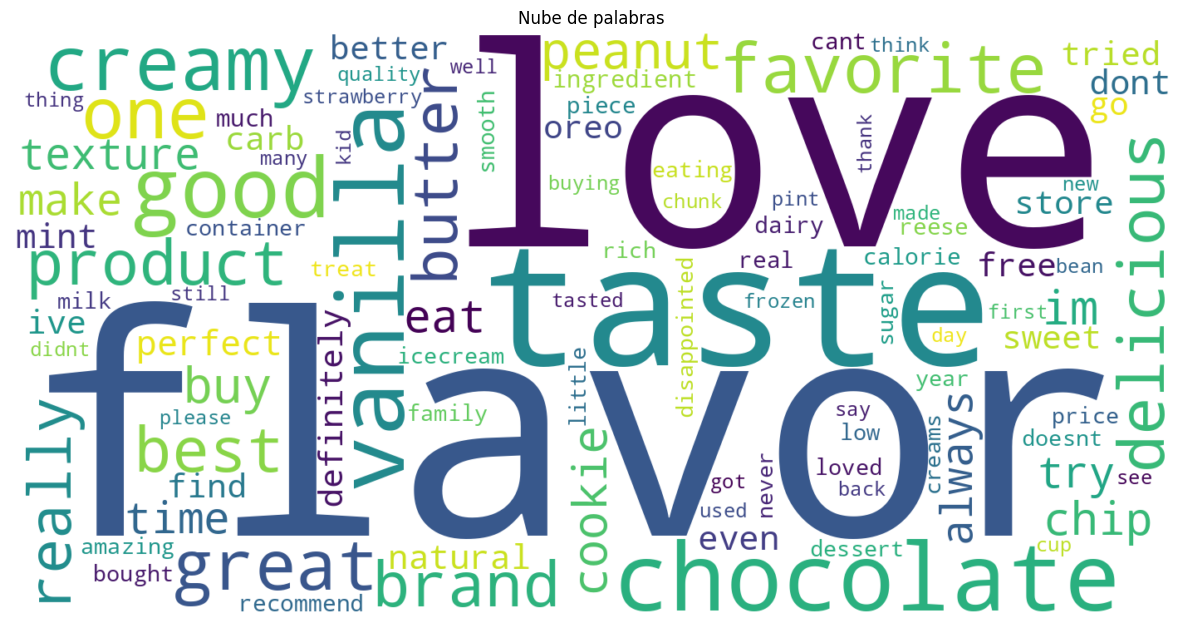

In [ ]:
reviews['clean_text'] = reviews['clean_text'].apply(
    lambda x: ' '.join(
        word for word in x.split()
        if word not in stop_words
    )
)
plt.figure(figsize=(15,8))

plt.imshow(wordcloud, interpolation='bilinear')

plt.axis('off')

plt.title('Nube de palabras')

plt.show()

## Análisis de polaridad

In [ ]:

reviews['sentiment'] = reviews['stars'].apply(
    lambda x: 'positive' if x >= 4 else 'negative'
)

reviews['sentiment'].value_counts()


,count
sentiment,
positive,3761
negative,1246


## WordCloud positivas

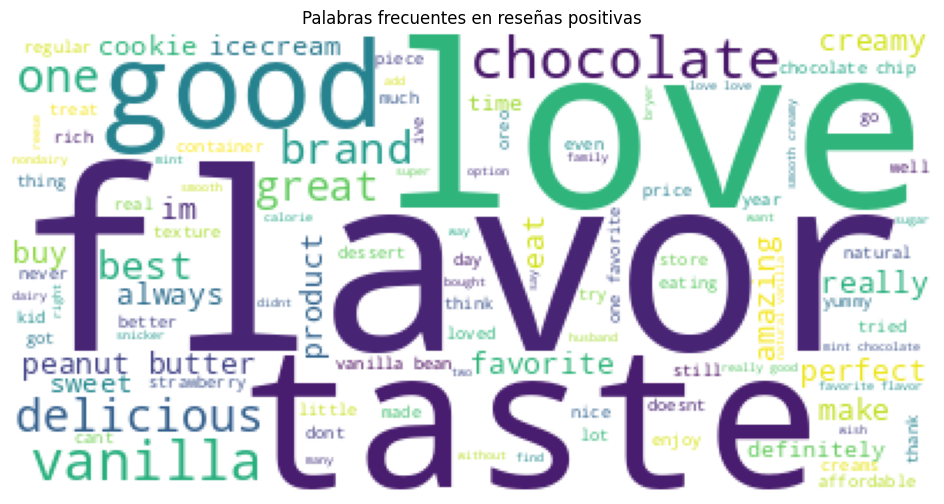

In [ ]:

positive_text = ' '.join(
    reviews[reviews['sentiment']=='positive']['clean_text']
)

positive_wc = WordCloud(
    background_color='white'
).generate(positive_text)

plt.figure(figsize=(12,6))

plt.imshow(positive_wc)
plt.axis('off')

plt.title('Palabras frecuentes en reseñas positivas')

plt.show()


## WordCloud negativas

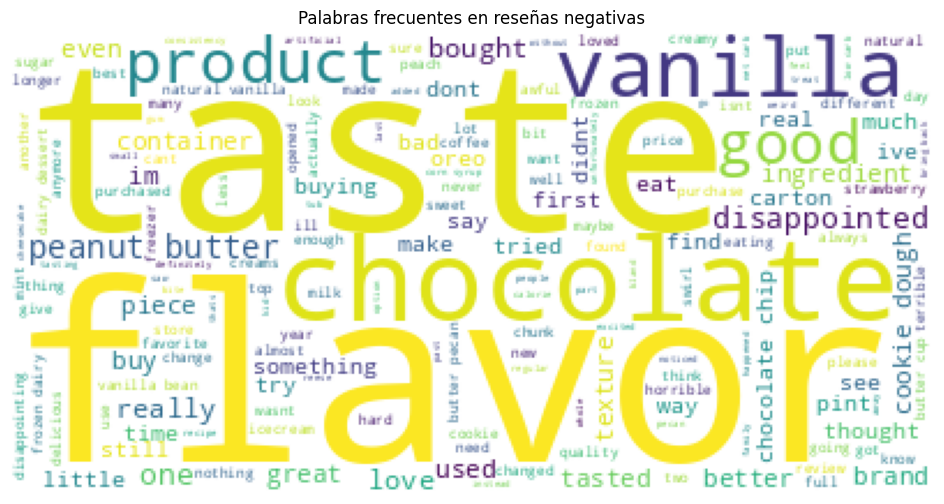

In [ ]:

negative_text = ' '.join(
    reviews[reviews['sentiment']=='negative']['clean_text']
)

negative_wc = WordCloud(
    background_color='white'
).generate(negative_text)

plt.figure(figsize=(12,6))

plt.imshow(negative_wc)
plt.axis('off')

plt.title('Palabras frecuentes en reseñas negativas')

plt.show()


## Bigramas frecuentes

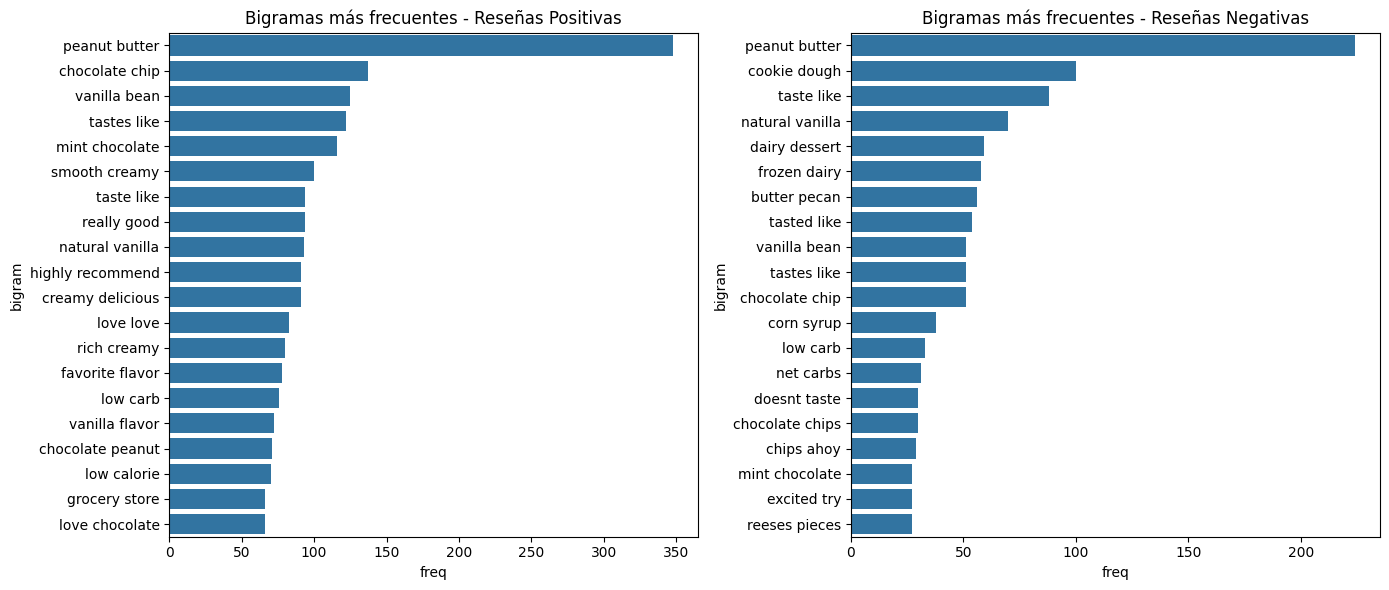

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def get_top_bigrams(data_subset, title):
    vectorizer = CountVectorizer(ngram_range=(2,2), stop_words='english')
    X = vectorizer.fit_transform(data_subset)
    sum_words = X.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vectorizer.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)[:20]
    return pd.DataFrame(words_freq, columns=['bigram', 'freq'])

# Separar por sentimiento
positive_df = reviews[reviews['sentiment'] == 'positive']['clean_text']
negative_df = reviews[reviews['sentiment'] == 'negative']['clean_text']

# Obtener top 20 bigramas para cada uno
top_pos = get_top_bigrams(positive_df, 'Positivos')
top_neg = get_top_bigrams(negative_df, 'Negativos')

# Graficar
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.barplot(data=top_pos, x='freq', y='bigram', ax=axes[0])
axes[0].set_title('Bigramas más frecuentes - Reseñas Positivas')

sns.barplot(data=top_neg, x='freq', y='bigram', ax=axes[1])
axes[1].set_title('Bigramas más frecuentes - Reseñas Negativas')

plt.tight_layout()
plt.show()

## Evolución temporal

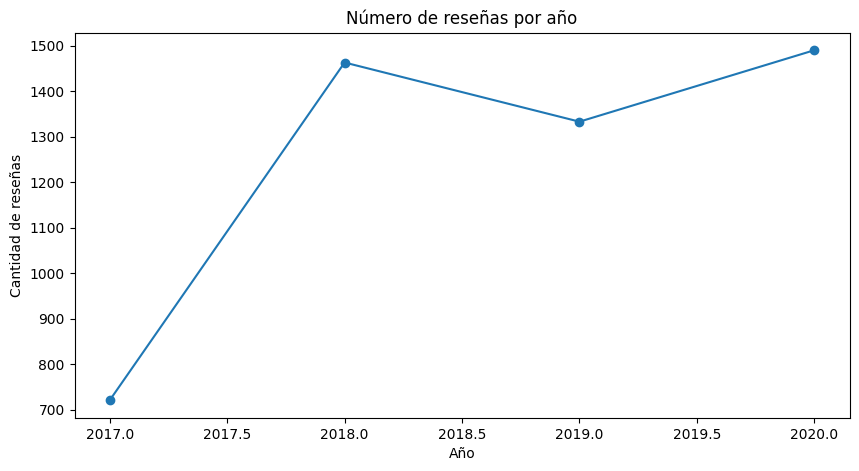

In [ ]:

reviews['date'] = pd.to_datetime(reviews['date'])

reviews_per_year = reviews.groupby(
    reviews['date'].dt.year
).size()

plt.figure(figsize=(10,5))

reviews_per_year.plot(marker='o')

plt.title('Número de reseñas por año')
plt.xlabel('Año')
plt.ylabel('Cantidad de reseñas')

plt.show()


## Instalar librerías avanzadas opcionales

In [ ]:

!pip install sentence-transformers
!pip install bertopic
